In [1]:
library(tidyverse)
library(dplyr)
library(ggplot2)
library(vegan)
library(ggstatsplot)
library(cowplot)
library(ggpubr)
library(patchwork)

── Attaching core tidyverse packages ─────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ───────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


You can cite this package as:mute────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conf

# File ordering================================================================================================================================

In [11]:
taxa_tab <- read.table("/ceph/projects/010_SweMaMi/bm.nowak/data/2025-12-09no_minimum_abundance_other_taxa_saliva_taxa_table_cleaned_both_tp.tsv", header = TRUE, sep ="\t", check.names = FALSE, quote='"') 
head(taxa_tab)
dim(taxa_tab)

,11601,921,7766,11497,10644,7547,10048,10681,13611,1054,⋯,19612,17589,18881,21225,20293,21180,21386,21930,17260,18891
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Prevotella_melaninogenica,7.46856,4.43305,2.01303,3.09323,2.18746,2.89516,5.46348,7.60818,2.66597,7.05540,⋯,2.27635,3.91719,0.01522,1.55264,4.93655,6.53807,3.30094,8.66169,3.93085,3.41636
TM7_phylum_sp_oral_taxon_352,3.14409,2.21632,0.27918,0.81149,0.10544,1.92240,1.88095,0.70932,2.10826,1.12378,⋯,2.03540,1.91947,0.99134,2.07174,0.46493,1.60654,3.36108,1.29958,1.20771,1.13150
Veillonella_dispar,3.16098,1.97065,5.15186,5.76151,3.67418,3.17602,4.86584,7.54436,0.60527,13.37827,⋯,2.17340,6.97362,9.72087,7.87567,7.26205,7.27621,5.88949,0.93840,12.13797,1.20559
Streptococcus_salivarius,6.66179,2.07087,9.56769,4.59215,7.84402,12.85163,7.59421,8.05424,0.36229,23.52221,⋯,3.08711,3.59449,18.06276,6.99764,9.51983,2.35358,6.62331,1.23692,12.70253,6.49664
Prevotella_pallens,1.09428,4.69337,0.48324,3.19061,0.00000,0.86855,4.79881,1.50316,1.29621,0.03604,⋯,0.62355,1.68677,0.52037,2.04457,2.32954,3.84069,0.71656,1.85049,1.24524,0.92643
Streptococcus_parasanguinis,5.05936,5.04811,4.55327,3.91857,2.32197,3.38418,3.75756,4.71644,1.78240,11.06978,⋯,1.56545,3.28812,9.99736,7.00401,2.73461,3.21385,7.10522,3.96688,9.57804,1.01967


[1]  846 1673

In [12]:
colnames(taxa_tab) |> head()

[1] "11601" "921"   "7766"  "11497" "10644" "7547"

In [13]:
taxa_tab[,1] |> head()

[1] 7.46856 3.14409 3.16098 6.66179 1.09428 5.05936

In [15]:
row.names(taxa_tab) |> head()
row.names(taxa_tab) |> tail()

[1] "Prevotella_melaninogenica"    "TM7_phylum_sp_oral_taxon_352"
[3] "Veillonella_dispar"           "Streptococcus_salivarius"    
[5] "Prevotella_pallens"           "Streptococcus_parasanguinis"

[1] "Brachybacterium_nesterenkovii"    "GGB6673_SGB99879"                
[3] "Streptococcus_dysgalactiae"       "Cutibacterium_granulosum"        
[5] "Corynebacterium_pseudogenitalium" "Other_taxa"

In [8]:
combined_fp_sp_tp1 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/saliva/tp1_nulliparous/2025-12-09_no_min_abundance_combined_nulliparous_fp_sp_tp1_saliva.csv", 
                               header = TRUE)


In [9]:
fp_tp1 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/saliva/tp1_nulliparous/2025-12-09_no_min_abundance_fp_tp1_nulliparous_saliva.csv", header = TRUE)
dim(fp_tp1)
head(fp_tp1)

[1]   9 566

,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,Age_groups,⋯,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis,Group
,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<chr>,<int>,<chr>,<lgl>,<lgl>,<int>,<chr>
1,S39fe1d7,NA,0,0,0,2018-06-23,P3db7da6,0,29,2,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
2,S50f102c,NA,0,0,0,2018-08-05,P50f102c,0,32,3,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
3,S735d77f,NA,0,0,0,2018-08-24,P735d77f,0,25,2,⋯,NA,NA,NA,NA,39,Spontaneous,NA,NA,0,First pregnancy
4,S9026714,NA,0,0,2,2019-01-02,P7ece52e,0,25,2,⋯,NA,NA,NA,NA,41,Induction,NA,NA,0,First pregnancy
5,Se5be4e8,NA,0,0,0,2018-07-03,Pbbb08bd,0,33,3,⋯,NA,NA,NA,NA,40,Spontaneous,NA,NA,0,First pregnancy
6,Sc9a3575,NA,0,0,0,2018-01-31,Pc9a3575,0,30,3,⋯,24,0,0,IUFD Jag fick havandeskapsförgiftning i v.22 och var tvungen att bli igångsatt. Flickan föddes i v. 24 +0 och överlevde tyvärr inte.,24,Induction,NA,NA,1,First pregnancy


In [10]:
sp_tp1 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/saliva/tp1_nulliparous/2025-12-09_no_min_abundance_sp_tp1_nulliparous_saliva.csv", header = TRUE)
dim(sp_tp1)
head(sp_tp1)

[1]   9 566

,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,Age_groups,⋯,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis,Group
,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,⋯,<lgl>,<lgl>,<lgl>,<lgl>,<int>,<chr>,<chr>,<int>,<int>,<chr>
1,S3db7da6,NA,0,0,1,2019-09-24,P3db7da6,0,30,3,⋯,NA,NA,NA,NA,39,Spontaneous,NA,NA,0,Second pregnancy
2,Sa957143,NA,0,0,1,2020-07-11,P50f102c,0,34,3,⋯,NA,NA,NA,NA,40,Spontaneous,NA,NA,0,Second pregnancy
3,S9deb4a6,NA,0,0,0,2019-11-20,P735d77f,0,26,2,⋯,NA,NA,NA,NA,39,Spontaneous,NA,NA,0,Second pregnancy
4,S7ece52e,NA,0,0,2,2020-10-21,P7ece52e,0,27,2,⋯,NA,NA,NA,NA,40,Spontaneous,NA,NA,0,Second pregnancy
5,Sbbb08bd,NA,0,0,1,2019-11-15,Pbbb08bd,0,34,3,⋯,NA,NA,NA,NA,38,Unlaboured c-section,NA,NA,0,Second pregnancy
6,S99e6192,NA,0,0,1,2020-05-15,Pc9a3575,0,32,3,⋯,NA,NA,NA,NA,28,Spontaneous,very_w28_31,1,1,Second pregnancy


In [16]:
dim(taxa_tab)
head(taxa_tab)

[1]  846 1673

,11601,921,7766,11497,10644,7547,10048,10681,13611,1054,⋯,19612,17589,18881,21225,20293,21180,21386,21930,17260,18891
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Prevotella_melaninogenica,7.46856,4.43305,2.01303,3.09323,2.18746,2.89516,5.46348,7.60818,2.66597,7.05540,⋯,2.27635,3.91719,0.01522,1.55264,4.93655,6.53807,3.30094,8.66169,3.93085,3.41636
TM7_phylum_sp_oral_taxon_352,3.14409,2.21632,0.27918,0.81149,0.10544,1.92240,1.88095,0.70932,2.10826,1.12378,⋯,2.03540,1.91947,0.99134,2.07174,0.46493,1.60654,3.36108,1.29958,1.20771,1.13150
Veillonella_dispar,3.16098,1.97065,5.15186,5.76151,3.67418,3.17602,4.86584,7.54436,0.60527,13.37827,⋯,2.17340,6.97362,9.72087,7.87567,7.26205,7.27621,5.88949,0.93840,12.13797,1.20559
Streptococcus_salivarius,6.66179,2.07087,9.56769,4.59215,7.84402,12.85163,7.59421,8.05424,0.36229,23.52221,⋯,3.08711,3.59449,18.06276,6.99764,9.51983,2.35358,6.62331,1.23692,12.70253,6.49664
Prevotella_pallens,1.09428,4.69337,0.48324,3.19061,0.00000,0.86855,4.79881,1.50316,1.29621,0.03604,⋯,0.62355,1.68677,0.52037,2.04457,2.32954,3.84069,0.71656,1.85049,1.24524,0.92643
Streptococcus_parasanguinis,5.05936,5.04811,4.55327,3.91857,2.32197,3.38418,3.75756,4.71644,1.78240,11.06978,⋯,1.56545,3.28812,9.99736,7.00401,2.73461,3.21385,7.10522,3.96688,9.57804,1.01967


In [17]:
tail(taxa_tab)

,11601,921,7766,11497,10644,7547,10048,10681,13611,1054,⋯,19612,17589,18881,21225,20293,21180,21386,21930,17260,18891
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Brachybacterium_nesterenkovii,0e+00,0e+00,0,0e+00,0,0e+00,0e+00,0e+00,0e+00,0,⋯,0,0,0,0e+00,0e+00,0,0,0e+00,0e+00,0e+00
GGB6673_SGB99879,0e+00,0e+00,0,0e+00,0,0e+00,0e+00,0e+00,0e+00,0,⋯,0,0,0,0e+00,0e+00,0,0,0e+00,0e+00,0e+00
Streptococcus_dysgalactiae,0e+00,0e+00,0,0e+00,0,0e+00,0e+00,0e+00,0e+00,0,⋯,0,0,0,0e+00,0e+00,0,0,0e+00,0e+00,0e+00
Cutibacterium_granulosum,0e+00,0e+00,0,0e+00,0,0e+00,0e+00,0e+00,0e+00,0,⋯,0,0,0,0e+00,0e+00,0,0,0e+00,0e+00,0e+00
Corynebacterium_pseudogenitalium,0e+00,0e+00,0,0e+00,0,0e+00,0e+00,0e+00,0e+00,0,⋯,0,0,0,0e+00,0e+00,0,0,0e+00,0e+00,0e+00
Other_taxa,1e-05,2e-05,0,6e-05,0,8e-05,3e-05,5e-05,2e-05,0,⋯,0,0,0,2e-05,4e-05,0,0,1e-05,1e-05,2e-05


In [18]:
# Filter because first col is species name, check length & that all add up to 100
store <- colSums(taxa_tab)
store
length(store) 

11601      921     7766    11497    10644     7547    10048    10681 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   13611     1054     9284     9482     7776    10343    10351    12972 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   10026    10357    10656     1392    10614    10873    11727     9665 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   10438     7701     1379     1049    11003    10312    11476    11099 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   10791    11667     9418    12715     1060     9290    10982     1152 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   10443     1078     7772     1077    10028    11660     1358    10304 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   11103     9429    11161    10454    11155     7211    11602     1673 
100.0000 100.0000 100.0001 100.0000 100.0001 100.0000 100.0000 100.0000 
   11766     9374     7774    10323    11011    11173     1123     7864 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   11700    10654     9468    10741    10715    10704     1386    10335 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0001 100.0000 
   10064    11482     9298     9288    11157     1079     1094    10020 
100.0000 100.0000 100.0001 100.0000 100.0000 100.0000 100.0000 100.0000 
    9688    10677    21667    17854    21666    18147    18596    17812 
100.0000 100.0000 100.0000 100.0001 100.0000 100.0000 100.0000 100.0000 
   19517    18873    20238    19200    19378    20541    18594    21504 
100.0000 100.0001 100.0000 100.0001 100.0001 100.0000 100.0000 100.0000 
   18855    20407    19422    19351    18605    19254    20046    19310 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   20380    20050    19803    18956    20811    18172    20044    17815 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   18026    18587    18931    20703    20895    18666    20665    19797 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0001 100.0000 100.0000 
   20701    20818    19931    20524    17826    19794    19911    20338 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   20632    19905    20088    20854    19353    20281    21973    17830 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   19283    19193    20451    20420    19964    21132    20308    19190 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0001 
   20068    19338    20248    20226    18708    21634    19881    19493 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   20550    18144    18962    20438    19115    20707    20305    18988 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   18979    11432    23329    23953     9574    23275    10506    22256 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   10432    23353     7231    10488    23562    23298    11390    23603 
100.0000 100.0000 100.0000 100.0000 100.0001 100.0000 100.0000 100.0000 
   10445    10989    22196     9483     7880    11439    20520     1693 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   23349    22327    22308    22142    11364    11212    11182    12952 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0001 100.0000 
   19916    11247    10794    10449    10508    11014    10913    12960 
100.0000 100.0000 100.0000 100.0001 100.0000 100.0000 100.0001 100.0000 
   10434    22269    11419    11054    10469    10771    10520    20523 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   20829    22183    10340    10459    10738    22157     1636    22191 
100.0000 100.0000 100.0000 100.0000 100.0001 100.0000 100.0000 100.0000 
    9921    20850    22176    11060    11384    17794     975

[1] 1673

In [23]:
grep("saliva", names(combined_fp_sp_tp1), value = TRUE)

[1] "kit3.salival_sample.barcode"        "kit1.salival_sample.barcode"       
[3] "kit1.salival_sample.datetime_taken" "kit2.salival_sample.barcode"       
[5] "kit2.salival_sample.datetime_taken" "kit3.salival_sample.datetime_taken"

In [24]:
# Read fp and sp metadata files to obtain barcodes, OBS $Group for FP has a SPACE at the end!!
combined_fp_sp_tp1$Group
fp_bc <- combined_fp_sp_tp1 |>
  filter(Group == "First pregnancy ") |>
  pull(kit1.salival_sample.barcode)
print(fp_bc)

[1] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [5] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [9] "First pregnancy " "Second pregnancy" "Second pregnancy" "Second pregnancy"
[13] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[17] "Second pregnancy" "Second pregnancy"

[1] 10368 10861 11161 13593 10856  1115 10654  9864   961


In [25]:
sp_bc <- combined_fp_sp_tp1 |>
  filter(Group == "Second pregnancy") |>
  pull(kit1.salival_sample.barcode)
print(sp_bc)

[1] 17523 19961 19676 23292 21011 21973 22236 20818 22000


In [26]:
# Save fp and sp in separate df 
fp_taxa <- taxa_tab[, colnames(taxa_tab) %in% fp_bc]
dim(fp_taxa)  

[1] 846   9

In [27]:
sp_taxa <- taxa_tab[, colnames(taxa_tab) %in% sp_bc]
dim(sp_taxa)
head(sp_taxa)

[1] 846   9

,20818,21973,21011,17523,19961,22236,23292,19676,22000
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Prevotella_melaninogenica,6.71577,1.11156,2.95073,0.32331,4.31933,1.40654,4.44167,6.59413,3.83742
TM7_phylum_sp_oral_taxon_352,5.65761,3.89699,3.86631,1.13414,4.76676,1.19881,6.27176,0.25329,3.23598
Veillonella_dispar,4.36465,1.36742,3.23901,4.00702,5.73056,3.66912,4.05041,2.56068,2.88717
Streptococcus_salivarius,1.46499,2.33622,6.02080,12.01942,8.89955,11.16620,4.55349,2.64088,7.23429
Prevotella_pallens,2.24977,1.55463,5.19754,0.55079,0.53024,0.35477,0.34879,1.49307,1.70957
Streptococcus_parasanguinis,3.22188,2.14846,1.88701,2.29062,3.48655,5.09958,5.06428,2.74218,4.24366


## Create file with filtered with kit1-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [28]:
# Save fp_bc and sp_bc to a combined df
combined_bc <- c(fp_bc, sp_bc)
length(combined_bc)
(combined_bc)

[1] 18

[1] 10368 10861 11161 13593 10856  1115 10654  9864   961 17523 19961 19676
[13] 23292 21011 21973 22236 20818 22000

In [30]:
# Keep only participants with valid bc
fp_kit1 <- combined_fp_sp_tp1 |>
  filter(kit1.salival_sample.barcode %in% fp_bc)
dim(fp_kit1)
fp_kit1$Group

[1]   9 566

[1] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[5] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[9] "First pregnancy "

In [31]:
sp_kit1 <- combined_fp_sp_tp1 |>
  filter(kit1.salival_sample.barcode %in% sp_bc)
dim(sp_kit1)
sp_kit1$Group

[1]   9 566

[1] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[5] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[9] "Second pregnancy"

In [32]:
sp_kit1$Studienummer

[1] "S3db7da6" "Sa957143" "S9deb4a6" "S7ece52e" "Sbbb08bd" "S99e6192" "S034bf15"
[8] "Sdab1897" "Se706703"

In [33]:
sp_kit1$kit1.salival_sample.barcode

[1] 17523 19961 19676 23292 21011 21973 22236 20818 22000

In [34]:
head(sp_kit1)

,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,Age_groups,⋯,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis,Group
,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<int>,<int>,<chr>
1,S3db7da6,NA,0,0,1,2019-09-24,P3db7da6,0,30,3,⋯,NA,NA,NA,NA,39,Spontaneous,NA,NA,0,Second pregnancy
2,Sa957143,NA,0,0,1,2020-07-11,P50f102c,0,34,3,⋯,NA,NA,NA,NA,40,Spontaneous,NA,NA,0,Second pregnancy
3,S9deb4a6,NA,0,0,0,2019-11-20,P735d77f,0,26,2,⋯,NA,NA,NA,NA,39,Spontaneous,NA,NA,0,Second pregnancy
4,S7ece52e,NA,0,0,2,2020-10-21,P7ece52e,0,27,2,⋯,NA,NA,NA,NA,40,Spontaneous,NA,NA,0,Second pregnancy
5,Sbbb08bd,NA,0,0,1,2019-11-15,Pbbb08bd,0,34,3,⋯,NA,NA,NA,NA,38,Unlaboured c-section,NA,NA,0,Second pregnancy
6,S99e6192,NA,0,0,1,2020-05-15,Pc9a3575,0,32,3,⋯,NA,NA,NA,NA,28,Spontaneous,very_w28_31,1,1,Second pregnancy


# Alpha Diversity===================================================================================================================================

## Shannon-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [35]:
fp_shan <- apply(fp_taxa, 2, diversity, index = "shannon")
head(fp_shan)

11161    10654    10861    13593     9864     1115 
4.226176 3.587286 3.694963 3.734604 3.754439 4.035120

In [36]:
sp_shan <- apply(sp_taxa, 2, diversity, index = "shannon")
head(sp_shan)

20818    21973    21011    17523    19961    22236 
4.048334 4.182023 3.977691 3.103090 3.579780 3.441995

In [37]:
summary(fp_shan)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  3.587   3.695   3.754   3.844   4.035   4.226 

In [38]:
summary(sp_shan)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  3.103   3.580   3.978   3.851   4.050   4.350 

In [39]:
df_shannon <-  data.frame(Shannon = c(fp_shan, sp_shan), Group = rep(c("Nulliparous", "Primiparous"), times = c(length(fp_shan), length(sp_shan))))
head(df_shannon)
class(df_shannon$Shannon)

,Shannon,Group
,<dbl>,<chr>
11161,4.226176,Nulliparous
10654,3.587286,Nulliparous
10861,3.694963,Nulliparous
13593,3.734604,Nulliparous
9864,3.754439,Nulliparous
1115,4.035120,Nulliparous


[1] "numeric"

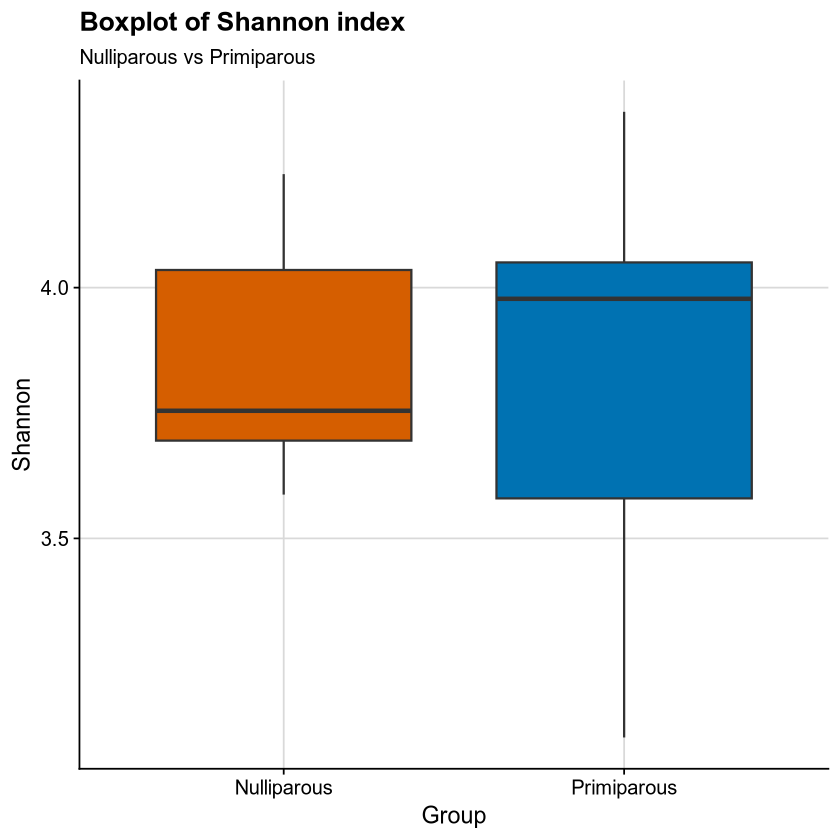

In [41]:
# Choose colors
clr <- c("Nulliparous" = "#D55E00", "Primiparous" = "#0072B2")

# Boxplot of shannon index
df_shannon |> 
  ggplot(aes(x = Group, y = Shannon, fill = Group)) +
  geom_boxplot() +
  scale_fill_manual(values = clr) +
  labs(
    title = "Boxplot of Shannon index",
      subtitle = "Nulliparous vs Primiparous",
    x = "Group",
    y = "Shannon",
  ) +
  theme_half_open() +
  background_grid() +
  theme(legend.position = "none")

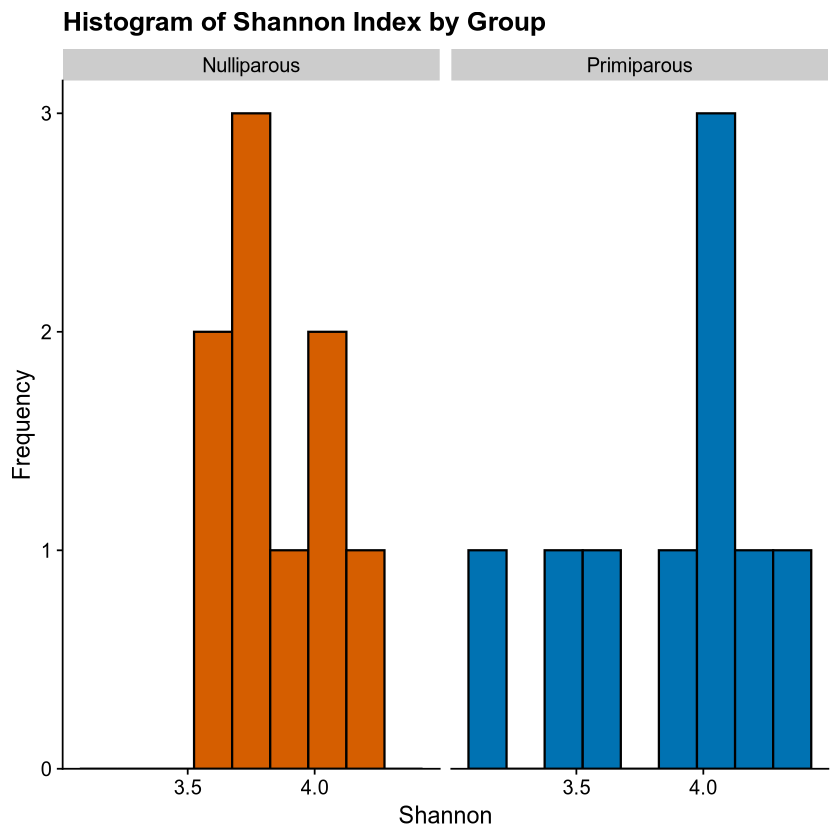

In [42]:
# Histogram of shannon index
df_shannon |> ggplot(aes(x = Shannon, fill = Group)) + 
  geom_histogram(binwidth = 0.15, position = "identity", col = "black") + 
  scale_fill_manual(values = clr) +
  labs(
    title = "Histogram of Shannon Index by Group",
    x = "Shannon",
    y = "Frequency"# Histogram of shannon index
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open() +
  facet_wrap(~Group) +
  theme(legend.position = "none") 

In [43]:
combined_fp_sp_tp1$kit1.salival_sample.barcode

[1] 10368 10861 11161 13593 10856  1115 10654  9864   961 17523 19961 19676
[13] 23292 21011 21973 22236 20818 22000

In [44]:
# after this Primiparous == NA
df_shannon_1 <- df_shannon |>
  rownames_to_column(var = "Sample_ID")
head(df_shannon_1)

,Sample_ID,Shannon,Group
,<chr>,<dbl>,<chr>
1,11161,4.226176,Nulliparous
2,10654,3.587286,Nulliparous
3,10861,3.694963,Nulliparous
4,13593,3.734604,Nulliparous
5,9864,3.754439,Nulliparous
6,1115,4.035120,Nulliparous


In [45]:
df_wide_shan <- pivot_wider(df_shannon_1, names_from = Group, values_from = Shannon)

In [46]:
# Extrac personal numbers for barcodes and add new column with pn to df_shannon_1
pn <- combined_fp_sp_tp1 |>
  filter(kit1.salival_sample.barcode %in% df_shannon_1$Sample_ID) %>% pull(Q1_Personnummer)
df_shannon_1$Personal_number <- pn
df_shannon_1$Personal_number
head(df_shannon_1)

[1] "P3db7da6" "P50f102c" "P735d77f" "P7ece52e" "Pbbb08bd" "Pc9a3575"
 [7] "Pca94a0f" "Pdab1897" "Pe706703" "P3db7da6" "P50f102c" "P735d77f"
[13] "P7ece52e" "Pbbb08bd" "Pc9a3575" "Pca94a0f" "Pdab1897" "Pe706703"

,Sample_ID,Shannon,Group,Personal_number
,<chr>,<dbl>,<chr>,<chr>
1,11161,4.226176,Nulliparous,P3db7da6
2,10654,3.587286,Nulliparous,P50f102c
3,10861,3.694963,Nulliparous,P735d77f
4,13593,3.734604,Nulliparous,P7ece52e
5,9864,3.754439,Nulliparous,Pbbb08bd
6,1115,4.035120,Nulliparous,Pc9a3575


In [157]:
# Write to file, name with no space between
#write.csv(df_shannon_1, file = paste0( "/ceph/projects/010_SweMaMi//bm.nowak/filtered_data/vaginal/tp1_nulliparous/tp1_alpha_beta_diversity/alpha/", Sys.Date(), "_tp1_shannon", ".csv"), row.names = FALSE)

In [47]:
which(duplicated(df_shannon_1$Personal_number) == TRUE)

[1] 10 11 12 13 14 15 16 17 18

In [48]:
length(which(duplicated(df_shannon_1$Personal_number) == TRUE))

[1] 9

In [50]:
shannon_wide <- df_shannon_1 |>
  select(Personal_number, Group, Shannon) |>
  pivot_wider(
    names_from = Group,
    values_from = Shannon
    )
shannon_wide |> head()

Personal_number,Nulliparous,Primiparous
<chr>,<dbl>,<dbl>
P3db7da6,4.226176,4.048334
P50f102c,3.587286,4.182023
P735d77f,3.694963,3.977691
P7ece52e,3.734604,3.103090
Pbbb08bd,3.754439,3.579780
Pc9a3575,4.035120,3.441995


In [51]:
shannon_wide$difference <- shannon_wide$Primiparous - shannon_wide$Nulliparous
shapiro.test(shannon_wide$difference)
#shannon_wide$difference


	Shapiro-Wilk normality test

data:  shannon_wide$difference
W = 0.9149, p-value = 0.3517


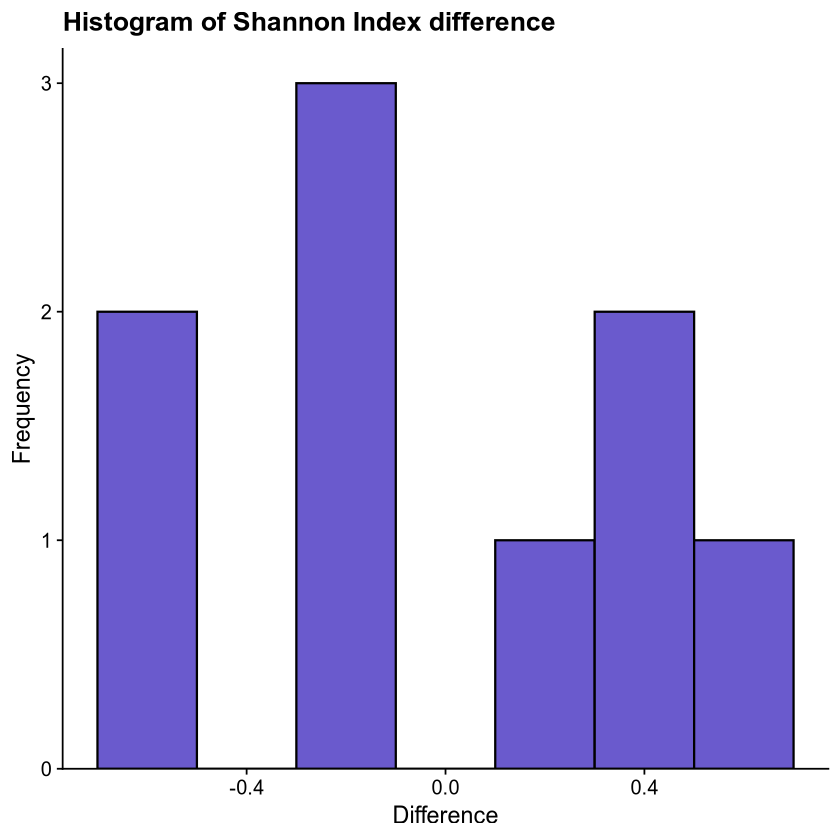

In [56]:
# View the distribution
shannon_wide |> ggplot(aes(x = difference)) + 
  geom_histogram(binwidth = 0.2, position = "identity", fill = "slateblue", col = "black") + 
  labs(
    title = "Histogram of Shannon Index difference",
    x = "Difference",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open()

In [57]:
t.test(Pair(Nulliparous, Primiparous) ~ 1,data = shannon_wide)


	Paired t-test

data:  Pair(Nulliparous, Primiparous)
t = -0.047675, df = 8, p-value = 0.9631
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -0.3564810  0.3420397
sample estimates:
mean difference 
   -0.007220651 


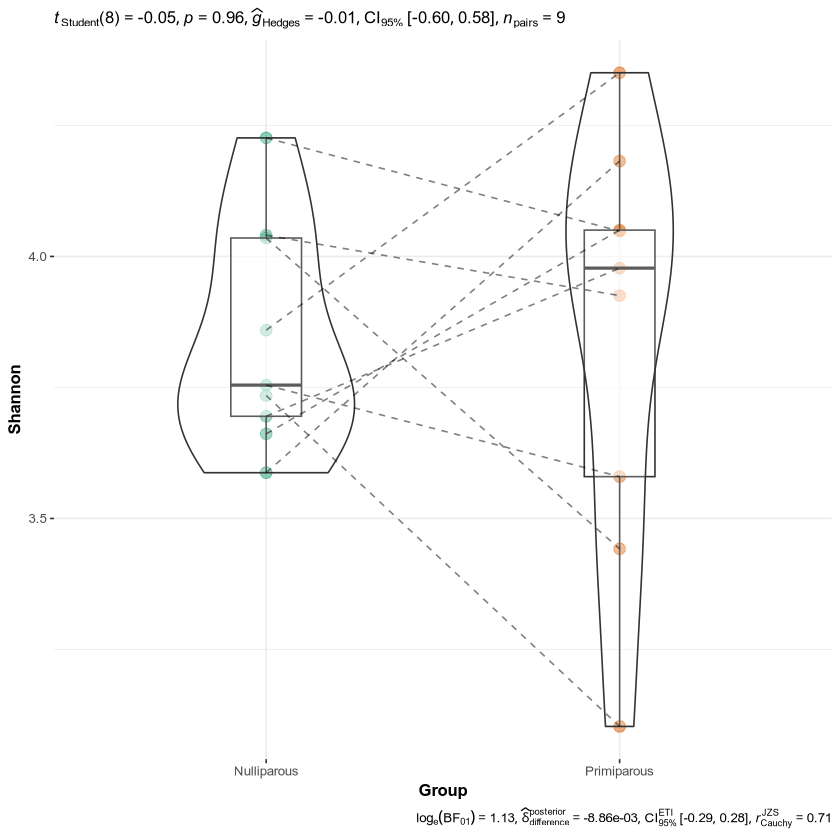

In [58]:
ggwithinstats( # paired samples
  data = df_shannon_1,
  x = Group,
  y = Shannon,
  centrality.plotting = FALSE # remove median
)

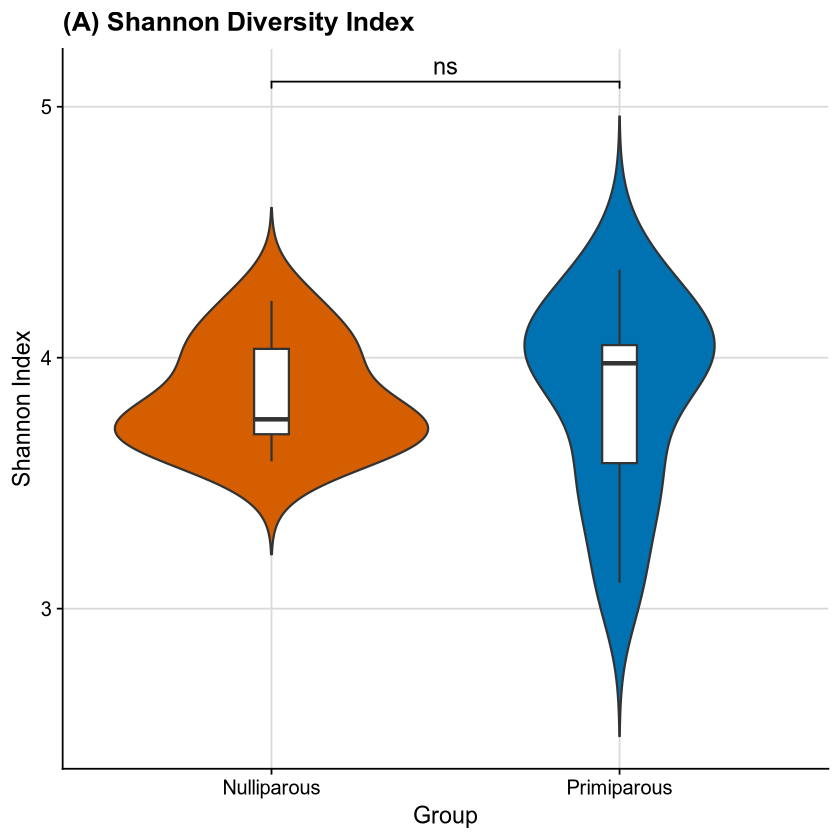

In [61]:
# Shannon Diversity Index Plot
plot_shan <- ggplot(df_shannon, aes(x = Group, y = Shannon, fill = Group)) +
  geom_violin(trim = FALSE) + 
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +
  scale_fill_manual(values = clr) +
  labs(title = "(A) Shannon Diversity Index", x = "Group", y = "Shannon Index") +
  theme_half_open() +
  background_grid() +
 theme(legend.position = "none") +
    geom_signif(
    annotations = "ns",                 
    y_position = 5.1,                 
    xmin = 1,
    xmax = 2,
    tip_length = 0.02,
    textsize = 5)
plot_shan

## Species richness--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [62]:
# 2 for columns, column = sample
fp_sr <- apply(fp_taxa, 2, specnumber)
head(fp_sr)

11161 10654 10861 13593  9864  1115 
  282   242   196   194   196   237

In [63]:
sp_sr <- apply(sp_taxa, 2, specnumber)
head(sp_sr)

20818 21973 21011 17523 19961 22236 
  204   181   234   125   195   225

In [64]:
summary(fp_sr)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  189.0   196.0   217.0   224.1   242.0   282.0 

In [65]:
summary(sp_sr)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  125.0   195.0   204.0   219.3   234.0   322.0 

In [66]:
# New df including richness
df_richness <-  data.frame(Species_richness = c(fp_sr, sp_sr), Group = rep(c("Nulliparous", "Primiparous"), times = c(length(fp_sr), length(sp_sr))))
head(df_richness)

,Species_richness,Group
,<int>,<chr>
11161,282,Nulliparous
10654,242,Nulliparous
10861,196,Nulliparous
13593,194,Nulliparous
9864,196,Nulliparous
1115,237,Nulliparous


In [67]:
# Check that num of participants correct
df_richness |> filter(Group == "Nulliparous") |> count()

n
<int>
9


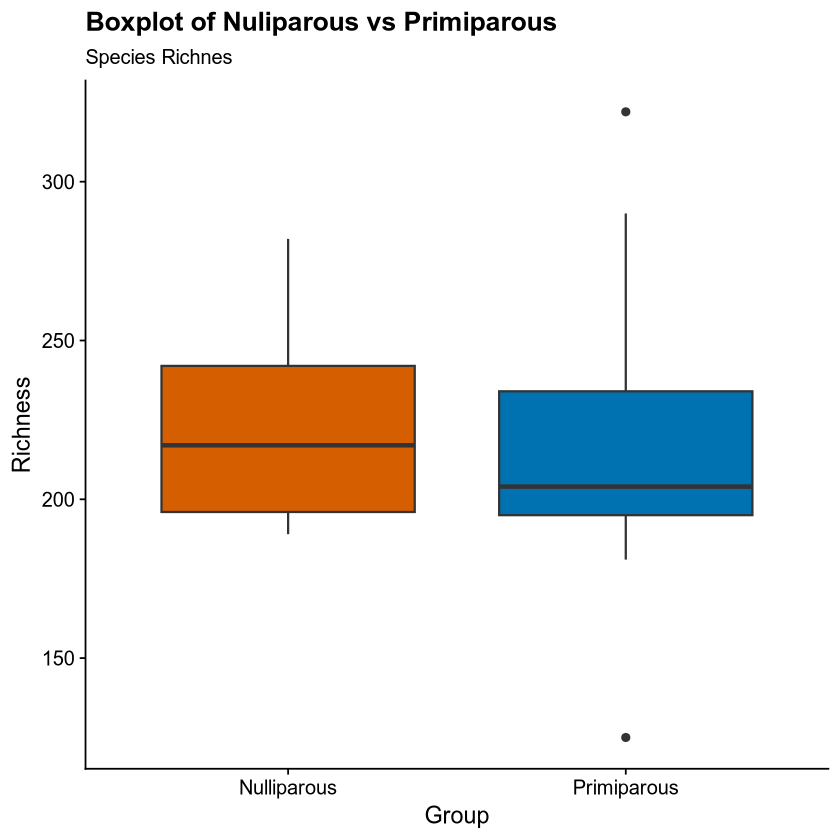

In [68]:
# Boxplot of species richness
df_richness |>
  ggplot(aes(x = Group, y = Species_richness, fill = Group)) +
  geom_boxplot() +
  scale_fill_manual(values = clr) +
  labs(
    x = "Group",
    y = "Richness",
    title = "Boxplot of Nuliparous vs Primiparous",
    subtitle = "Species Richnes"
  ) +
  theme_half_open() +
  theme(legend.position = "none") 

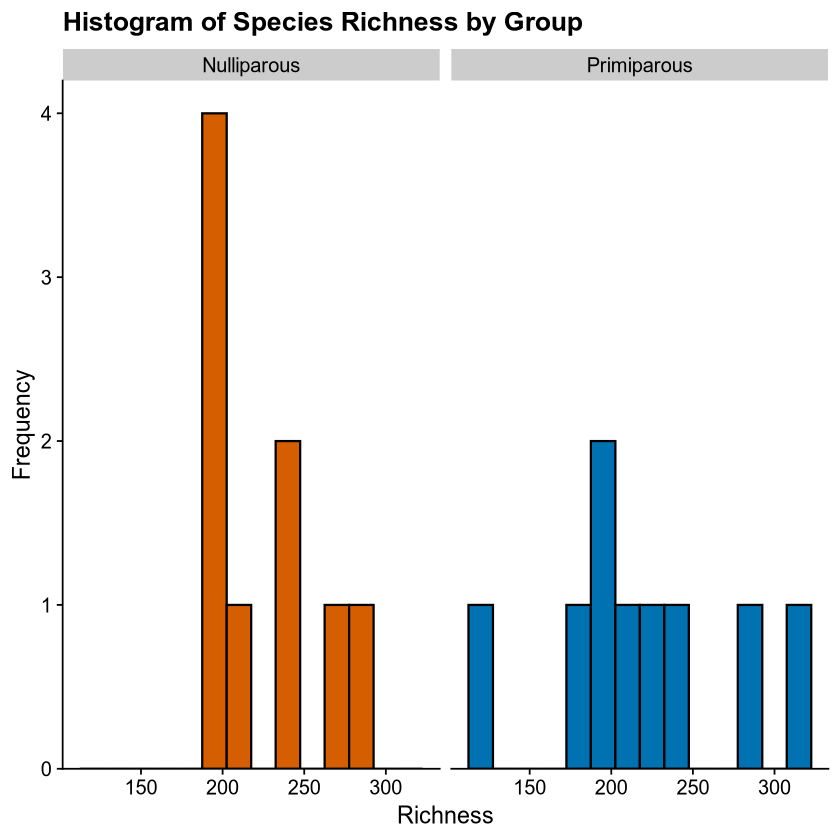

In [74]:
# Histogram of species richness
df_richness |> ggplot(aes(x = Species_richness, fill = Group)) +
  geom_histogram(binwidth = 15, position = "identity", col = "black") +
  scale_fill_manual(values = clr) +
  labs(
    title = "Histogram of Species Richness by Group",
    x = "Richness",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open() +
  facet_wrap(~Group) +
  theme(legend.position = "none") 


In [75]:
# Calculate difference for Shapiro test
df_richness_1 <- df_richness |>
  rownames_to_column(var = "Sample_ID")
head(df_richness_1)

,Sample_ID,Species_richness,Group
,<chr>,<int>,<chr>
1,11161,282,Nulliparous
2,10654,242,Nulliparous
3,10861,196,Nulliparous
4,13593,194,Nulliparous
5,9864,196,Nulliparous
6,1115,237,Nulliparous


In [76]:
# Extrac personal numbers for barcodes and add new column with pn to df_richness_1
pn_richness <- combined_fp_sp_tp1 |>
  filter(kit1.salival_sample.barcode %in% df_richness_1$Sample_ID) %>% pull(Q1_Personnummer)

In [77]:
# Add column with pn
df_richness_1$Personal_number <- pn_richness
length(df_richness_1$Personal_number)

[1] 18

In [177]:
length(df_richness_1$Personal_number)
head(df_richness_1)

[1] 52

,Sample_ID,Species_richness,Group,Personal_number
,<chr>,<int>,<chr>,<chr>
1,FF00653546,29,Nulliparous,P159f9c8
2,FB02825409,24,Nulliparous,P1f862a6
3,FF02015345,17,Nulliparous,P1f95844
4,FF00653065,8,Nulliparous,P3cac7b0
5,FF02014263,3,Nulliparous,P3db7da6
6,FF02015432,37,Nulliparous,P424fd61


In [78]:
which(duplicated(df_richness_1$Personal_number) == TRUE)

[1] 10 11 12 13 14 15 16 17 18

In [79]:
length(which(duplicated(df_richness_1$Personal_number) == TRUE))

[1] 9

In [80]:
#write.csv(df_richness_1, file = paste0( "/ceph/projects/010_SweMaMi//bm.nowak/filtered_data/vaginal/tp1_nulliparous/tp1_alpha_beta_diversity/alpha/", 
 #                                      Sys.Date(), "_tp1_richness", ".csv"), row.names = FALSE)

In [81]:
richness_wide <- df_richness_1 |>
  select(Personal_number, Group, Species_richness) |>
  pivot_wider(
             names_from = Group,
             values_from = Species_richness
           )

In [82]:
# Test data distribution
richness_wide$difference <- richness_wide$Primiparous - richness_wide$Nulliparous
shapiro.test(richness_wide$difference)


	Shapiro-Wilk normality test

data:  richness_wide$difference
W = 0.91227, p-value = 0.3321


In [83]:
head(richness_wide)

Personal_number,Nulliparous,Primiparous,difference
<chr>,<int>,<int>,<int>
P3db7da6,282,204,-78
P50f102c,242,181,-61
P735d77f,196,234,38
P7ece52e,194,125,-69
Pbbb08bd,196,195,-1
Pc9a3575,237,225,-12


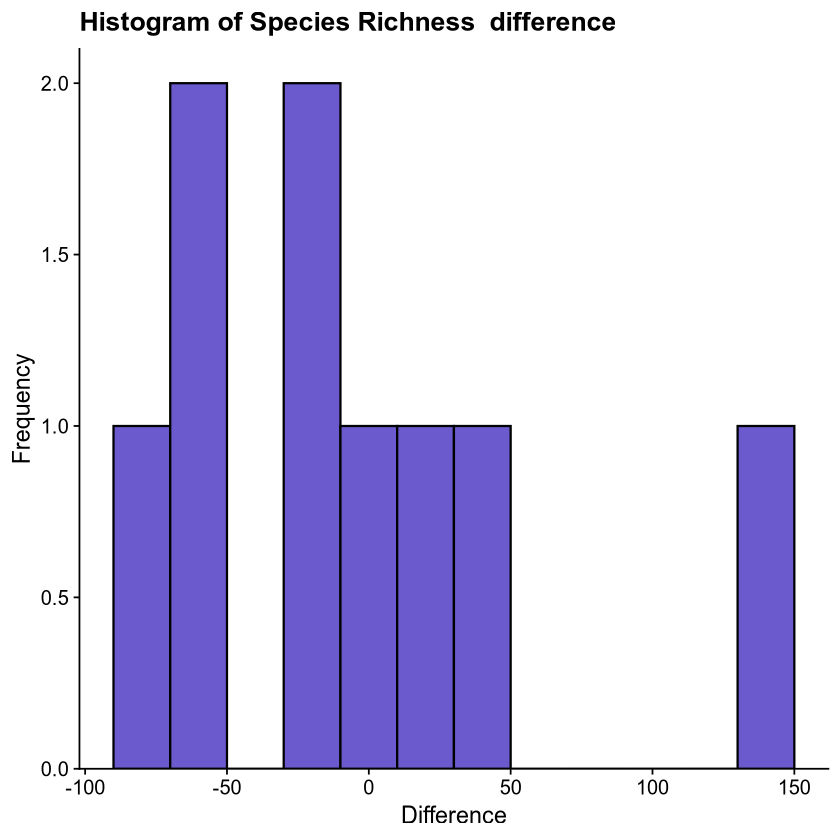

In [93]:
# Data distribution visualization
richness_wide |> ggplot(aes(x = difference)) + 
  geom_histogram(binwidth = 20, position = "identity", fill = "slateblue", col = "black") + 
  labs(
    title = "Histogram of Species Richness  difference",
    x = "Difference",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open()

In [94]:
t.test(Pair(Nulliparous, Primiparous) ~ 1, data = richness_wide)


	Paired t-test

data:  Pair(Nulliparous, Primiparous)
t = 0.21771, df = 8, p-value = 0.8331
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -45.82863  55.38419
sample estimates:
mean difference 
       4.777778 


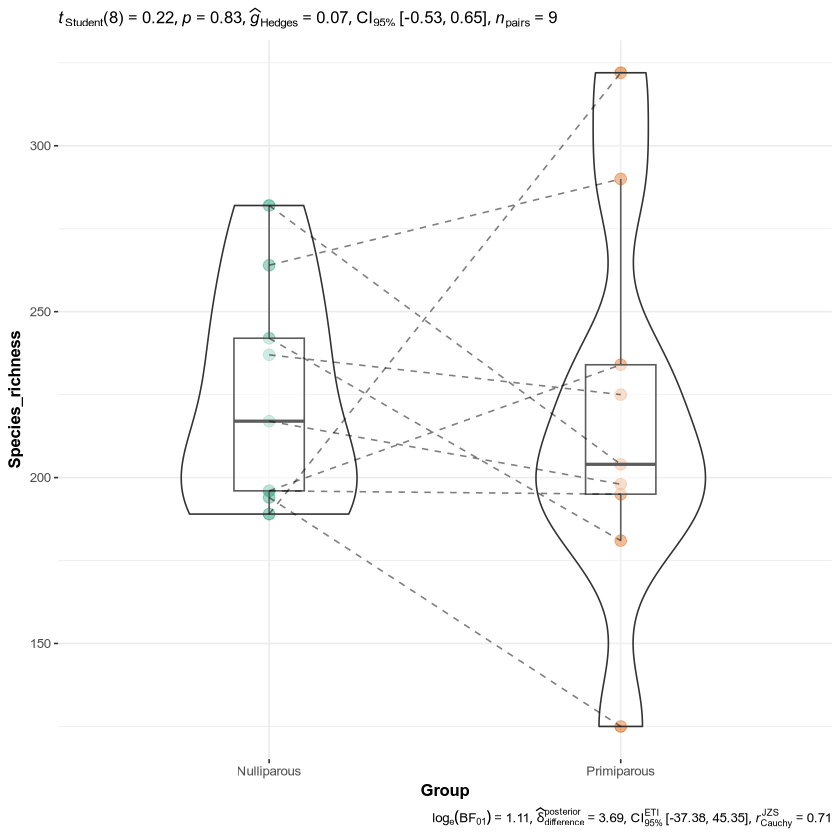

In [95]:
# view the data distribution
# plot with statistical results
ggwithinstats( # paired samples
  data = df_richness,
  x = Group,
  y = Species_richness,
  centrality.plotting = FALSE # remove median
)

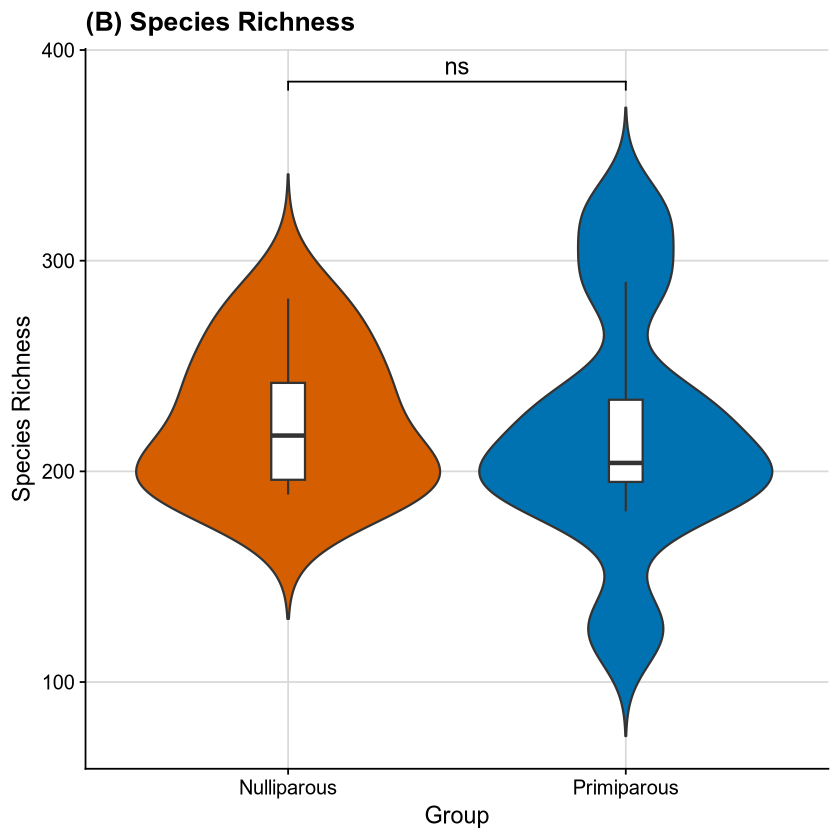

In [99]:
# Shannon Diversity Index Plot
plot_richness <- ggplot(df_richness, aes(x = Group, y = Species_richness, fill = Group)) +
  geom_violin(trim = FALSE) + 
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +
  scale_fill_manual(values = clr) +
  labs(
    title = "(B) Species Richness", 
    x = "Group", 
    y = "Species Richness"
    ) +
  theme_half_open() +
  background_grid() +
  theme(legend.position = "none") +
geom_signif(
    annotations = "ns",                 
    y_position = 385,                 
    xmin = 1,
    xmax = 2,
    tip_length = 0.02,
    textsize = 5)
plot_richness

## Evenness ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [100]:
# Fp
case_pie_small <- fp_shan/log(fp_sr)
case_pie_small

11161     10654     10861     13593      9864      1115       961     10856 
0.7490688 0.6535483 0.7000535 0.7089417 0.7113219 0.7379435 0.6566395 0.7362640 
    10368 
0.7510355

In [101]:
summary(case_pie_small)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.6535  0.7001  0.7113  0.7116  0.7379  0.7510 

In [102]:
# Sp
control_pie <- sp_shan/log(sp_sr)
control_pie

20818     21973     21011     17523     19961     22236     23292     19676 
0.7612340 0.8044676 0.7291397 0.6426860 0.6788888 0.6355117 0.7143364 0.7533855 
    22000 
0.7422445

In [103]:
summary(control_pie)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.6355  0.6789  0.7291  0.7180  0.7534  0.8045 

In [104]:
df_evenness <-  data.frame(Evenness = c(case_pie_small, control_pie), Group = rep(c("Nulliparous", "Primiparous"), times = c(length(case_pie_small), length(control_pie))))
head(df_evenness)
class(df_evenness$Evenness)

,Evenness,Group
,<dbl>,<chr>
11161,0.7490688,Nulliparous
10654,0.6535483,Nulliparous
10861,0.7000535,Nulliparous
13593,0.7089417,Nulliparous
9864,0.7113219,Nulliparous
1115,0.7379435,Nulliparous


[1] "numeric"

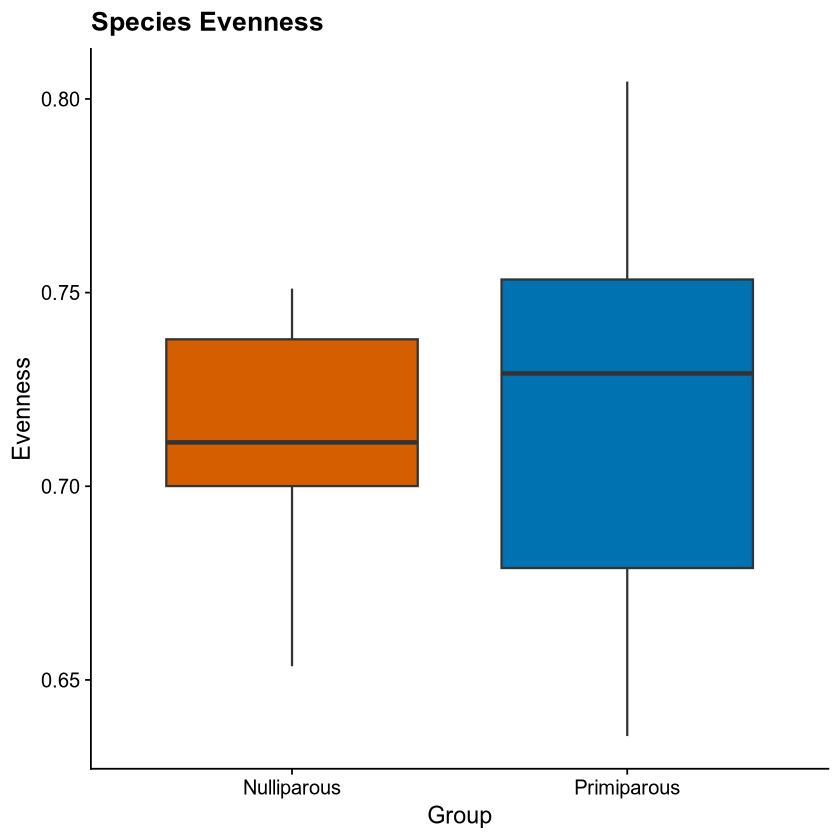

In [105]:
# Boxplot of evenness
df_evenness |> ggplot(aes(x = Group, y = Evenness, fill = Group)) +
  geom_boxplot() +
  scale_fill_manual(values = clr) +
  labs(
    x = "Group",
    y = "Evenness",
    title = "Species Evenness"
  ) +
  theme_half_open() +
  theme(legend.position = "none")

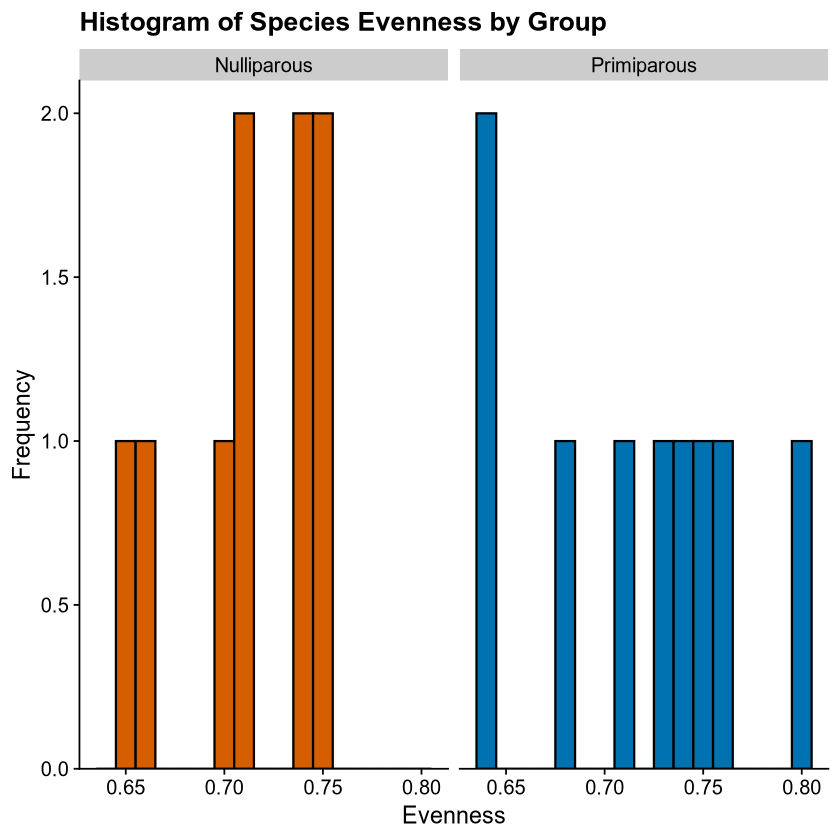

In [107]:
# Histogram of evenness
df_evenness |> ggplot(aes(x = Evenness, fill = Group)) + 
  geom_histogram(binwidth = 0.01, position = "identity", col = "black") + 
  scale_fill_manual(values = clr) +
  labs(
    title = "Histogram of Species Evenness by Group",
    x = "Evenness",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open() +
  facet_wrap(~Group) +
  theme(legend.position = "none") 


In [108]:
df_evenness_2 <- df_evenness |>
  rownames_to_column(var = "Sample_ID")
head(df_evenness_2)

,Sample_ID,Evenness,Group
,<chr>,<dbl>,<chr>
1,11161,0.7490688,Nulliparous
2,10654,0.6535483,Nulliparous
3,10861,0.7000535,Nulliparous
4,13593,0.7089417,Nulliparous
5,9864,0.7113219,Nulliparous
6,1115,0.7379435,Nulliparous


In [109]:
# Find and extract pn
pn_evenness <- combined_fp_sp_tp1 |>
  filter(kit1.salival_sample.barcode %in% df_evenness_2$Sample_ID) |> pull(Q1_Personnummer)
pn_evenness

[1] "P3db7da6" "P50f102c" "P735d77f" "P7ece52e" "Pbbb08bd" "Pc9a3575"
 [7] "Pca94a0f" "Pdab1897" "Pe706703" "P3db7da6" "P50f102c" "P735d77f"
[13] "P7ece52e" "Pbbb08bd" "Pc9a3575" "Pca94a0f" "Pdab1897" "Pe706703"

In [110]:
df_evenness_2$Personal_number <- pn_evenness
head(df_evenness_2)
dim(df_evenness_2)

,Sample_ID,Evenness,Group,Personal_number
,<chr>,<dbl>,<chr>,<chr>
1,11161,0.7490688,Nulliparous,P3db7da6
2,10654,0.6535483,Nulliparous,P50f102c
3,10861,0.7000535,Nulliparous,P735d77f
4,13593,0.7089417,Nulliparous,P7ece52e
5,9864,0.7113219,Nulliparous,Pbbb08bd
6,1115,0.7379435,Nulliparous,Pc9a3575


[1] 18  4

In [111]:
#write.csv(df_evenness_2, file = paste0( "/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/vaginal/tp1_nulliparous/tp1_alpha_beta_diversity/alpha/", Sys.Date(), "_tp1_evenness", ".csv"), row.names = FALSE)

In [112]:
evenness_wide <- df_evenness_2 |>
  select(Personal_number, Group, Evenness) |>
  pivot_wider(
    names_from = Group,
    values_from = Evenness
  )
head(evenness_wide)

Personal_number,Nulliparous,Primiparous
<chr>,<dbl>,<dbl>
P3db7da6,0.7490688,0.7612340
P50f102c,0.6535483,0.8044676
P735d77f,0.7000535,0.7291397
P7ece52e,0.7089417,0.6426860
Pbbb08bd,0.7113219,0.6788888
Pc9a3575,0.7379435,0.6355117


In [113]:
evenness_wide$difference <- evenness_wide$Primiparous - evenness_wide$Nulliparous
shapiro.test(evenness_wide$difference)


	Shapiro-Wilk normality test

data:  evenness_wide$difference
W = 0.96677, p-value = 0.8658


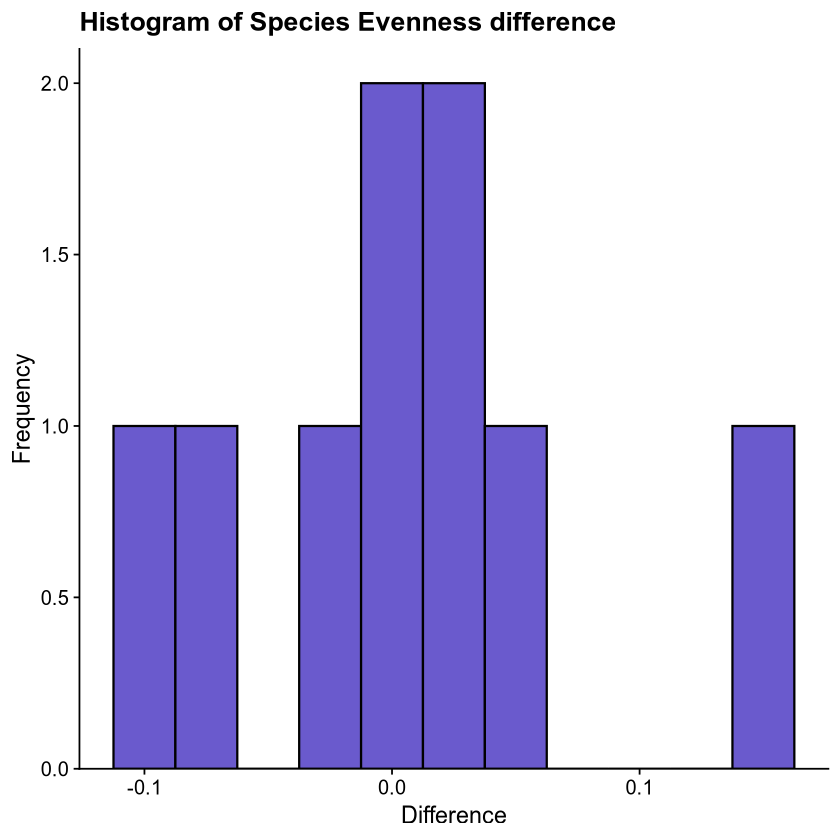

In [117]:
# Visualize data distribution
evenness_wide |> ggplot(aes(x = difference)) + 
  geom_histogram(binwidth = 0.025, position = "identity", fill = "slateblue", col = "black") + 
  labs(
    title = "Histogram of Species Evenness difference",
    x = "Difference",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open()

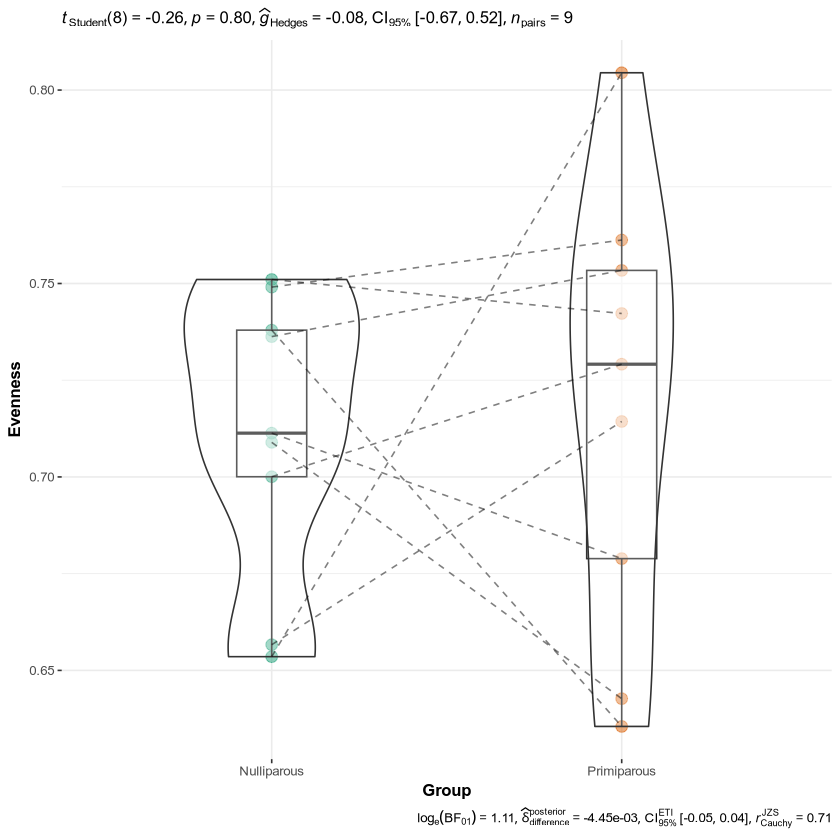

In [118]:
# view the data distribution
# plot with statistical results
ggwithinstats( # paired samples
  data = df_evenness,
  x = Group,
  y = Evenness,
 # type = "nonparametric", # for wilcoxon
  centrality.plotting = FALSE # remove median
)

In [119]:
test_evenness <- t.test(Pair(Nulliparous, Primiparous) ~1, data = evenness_wide)
test_evenness


	Paired t-test

data:  Pair(Nulliparous, Primiparous)
t = -0.25938, df = 8, p-value = 0.8019
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -0.06272390  0.05004001
sample estimates:
mean difference 
   -0.006341941 


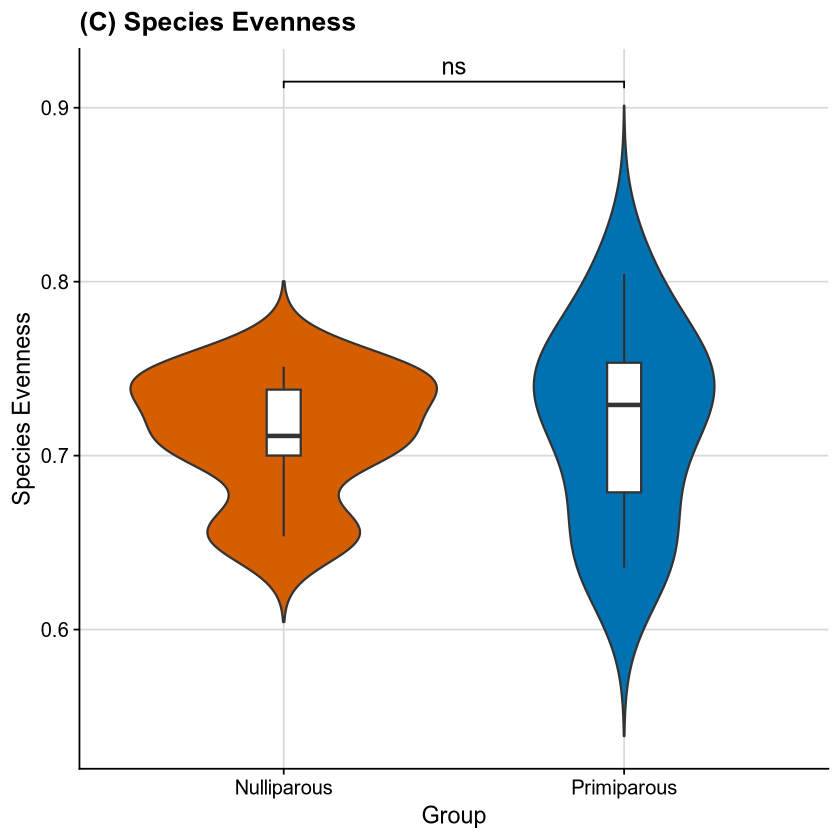

In [124]:
# Violin plots of evenness
plot_evenness <- df_evenness_2 |> ggplot(aes(x = Group, y = Evenness, fill = Group)) +
  geom_violin(trim = FALSE) + 
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +
  scale_fill_manual(values = clr) +
  labs(
    x = "Group",
    y = "Species Evenness",
    title = "(C) Species Evenness"
  ) +
  theme_half_open() +
  theme(legend.position = "none") +
  background_grid() +
  theme(legend.position = "none") +
geom_signif(
    annotations = "ns",                 
    y_position = 0.915,                 
    xmin = 1,
    xmax = 2,
    tip_length = 0.02,
    textsize = 5)
plot_evenness

## Simpson's index---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [125]:
# 2 for columns, column = sample
fp_simpson <- apply(fp_taxa, 2, diversity, index = "simpson")
head(fp_simpson)

11161     10654     10861     13593      9864      1115 
0.9659889 0.9535661 0.9574395 0.9512552 0.9549042 0.9727676

In [127]:
sp_simpson <- apply(sp_taxa, 2, diversity, index = "simpson")
head(fp_simpson)

11161     10654     10861     13593      9864      1115 
0.9659889 0.9535661 0.9574395 0.9512552 0.9549042 0.9727676

In [128]:
df_simpson <-  data.frame(Simpson = c(fp_simpson, sp_simpson), Group = rep(c("Nulliparous", "Primiparous"), times = c(length(fp_simpson), length(sp_simpson))))
head(df_simpson)
class(df_simpson$Simpson)

,Simpson,Group
,<dbl>,<chr>
11161,0.9659889,Nulliparous
10654,0.9535661,Nulliparous
10861,0.9574395,Nulliparous
13593,0.9512552,Nulliparous
9864,0.9549042,Nulliparous
1115,0.9727676,Nulliparous


[1] "numeric"

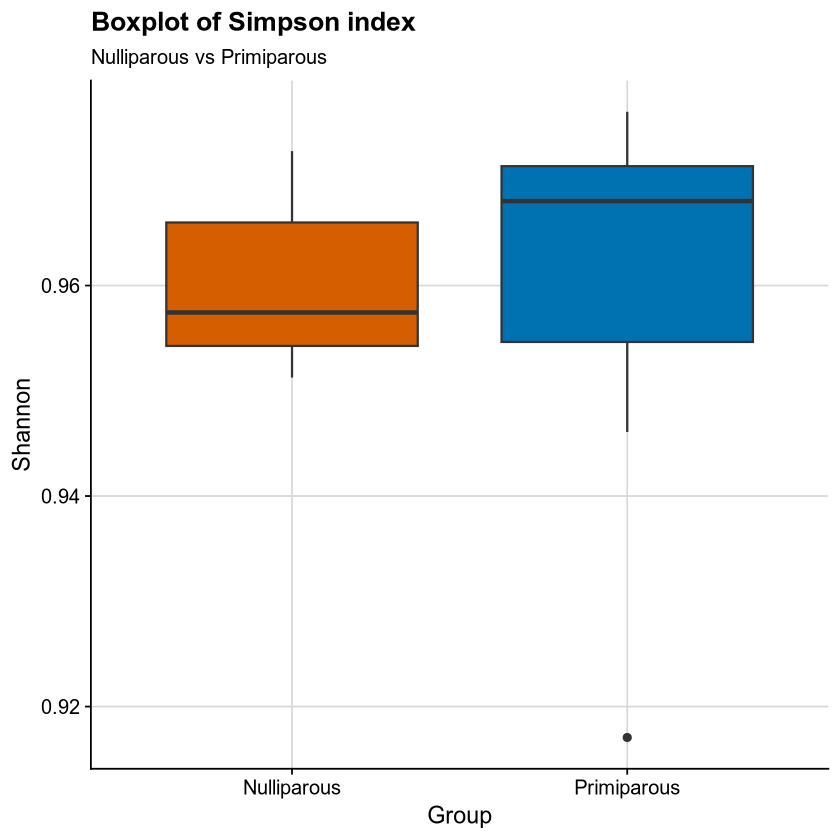

In [129]:
# Boxplot of Simpson index
df_simpson |> 
  ggplot(aes(x = Group, y = Simpson, fill = Group)) +
  geom_boxplot() +
  scale_fill_manual(values = clr) +
  labs(
    title = "Boxplot of Simpson index",
      subtitle = "Nulliparous vs Primiparous",
    x = "Group",
    y = "Shannon",
  ) +
  theme_half_open() +
  background_grid() +
  theme(legend.position = "none")

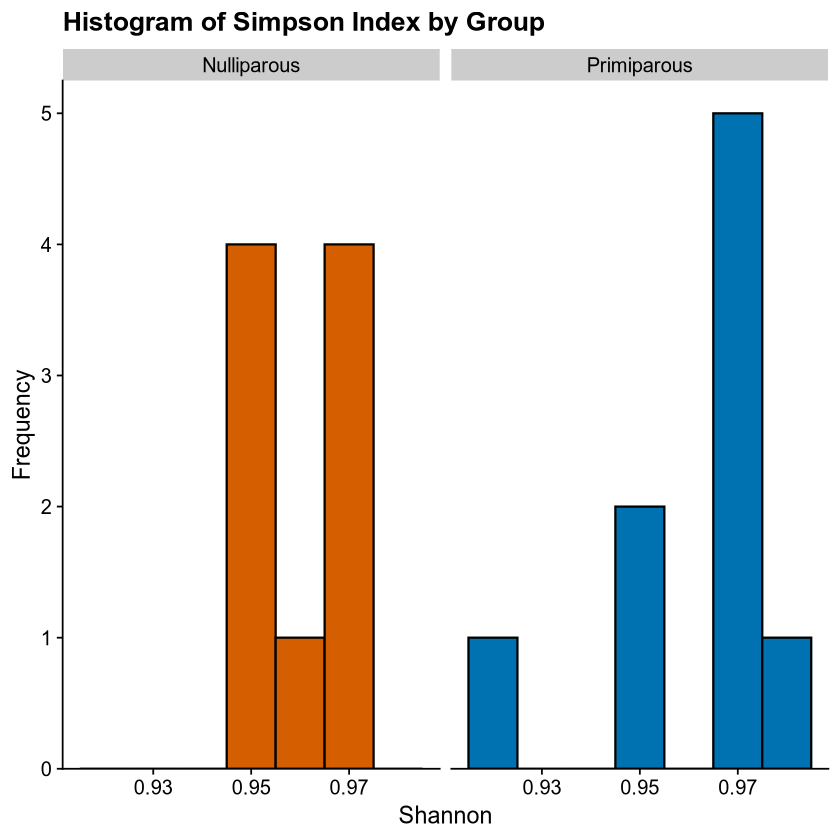

In [132]:
# Histogram of simpson index
df_simpson |> ggplot(aes(x = Simpson, fill = Group)) + 
  geom_histogram(binwidth = 0.01, position = "identity", col = "black") + 
  scale_fill_manual(values = clr) +
  labs(
    title = "Histogram of Simpson Index by Group",
    x = "Shannon",
    y = "Frequency"# Histogram of shannon index
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open() +
  facet_wrap(~Group) +
  theme(legend.position = "none") 

In [133]:
df_simpson_1 <- df_simpson |>
  rownames_to_column(var = "Sample_ID")
head(df_simpson_1)

,Sample_ID,Simpson,Group
,<chr>,<dbl>,<chr>
1,11161,0.9659889,Nulliparous
2,10654,0.9535661,Nulliparous
3,10861,0.9574395,Nulliparous
4,13593,0.9512552,Nulliparous
5,9864,0.9549042,Nulliparous
6,1115,0.9727676,Nulliparous


In [134]:
# Extrac personal numbers for barcodes and add new column with pn to 
pn_simpson<- combined_fp_sp_tp1 |>
  filter(kit1.salival_sample.barcode %in% df_simpson_1$Sample_ID) %>% pull(Q1_Personnummer)
# Add column with pn
df_simpson_1$Personal_number <- pn_simpson
df_simpson_1$Personal_number

[1] "P3db7da6" "P50f102c" "P735d77f" "P7ece52e" "Pbbb08bd" "Pc9a3575"
 [7] "Pca94a0f" "Pdab1897" "Pe706703" "P3db7da6" "P50f102c" "P735d77f"
[13] "P7ece52e" "Pbbb08bd" "Pc9a3575" "Pca94a0f" "Pdab1897" "Pe706703"

In [135]:
length(which(duplicated(df_simpson_1$Personal_number) == TRUE))

[1] 9

In [136]:
#write.csv(df_simpson_1, file = paste0( "/ceph/projects/010_SweMaMi//bm.nowak/filtered_data/vaginal/tp1_nulliparous/tp1_alpha_beta_diversity/alpha/", Sys.Date(), "_tp1_simpson", ".csv"), row.names = FALSE)

In [137]:
simpson_wide <- df_simpson_1 |>
  select(Personal_number, Group, Simpson) |>
  pivot_wider(
             names_from = Group,
             values_from = Simpson
           )
head(simpson_wide)

Personal_number,Nulliparous,Primiparous
<chr>,<dbl>,<dbl>
P3db7da6,0.9659889,0.9713396
P50f102c,0.9535661,0.9765032
P735d77f,0.9574395,0.9682692
P7ece52e,0.9512552,0.9170614
Pbbb08bd,0.9549042,0.9546390
Pc9a3575,0.9727676,0.9460826


In [138]:
# Test data distribution
simpson_wide$difference <- simpson_wide$Primiparous - simpson_wide$Nulliparous
shapiro.test(simpson_wide$difference)


	Shapiro-Wilk normality test

data:  simpson_wide$difference
W = 0.87614, p-value = 0.143


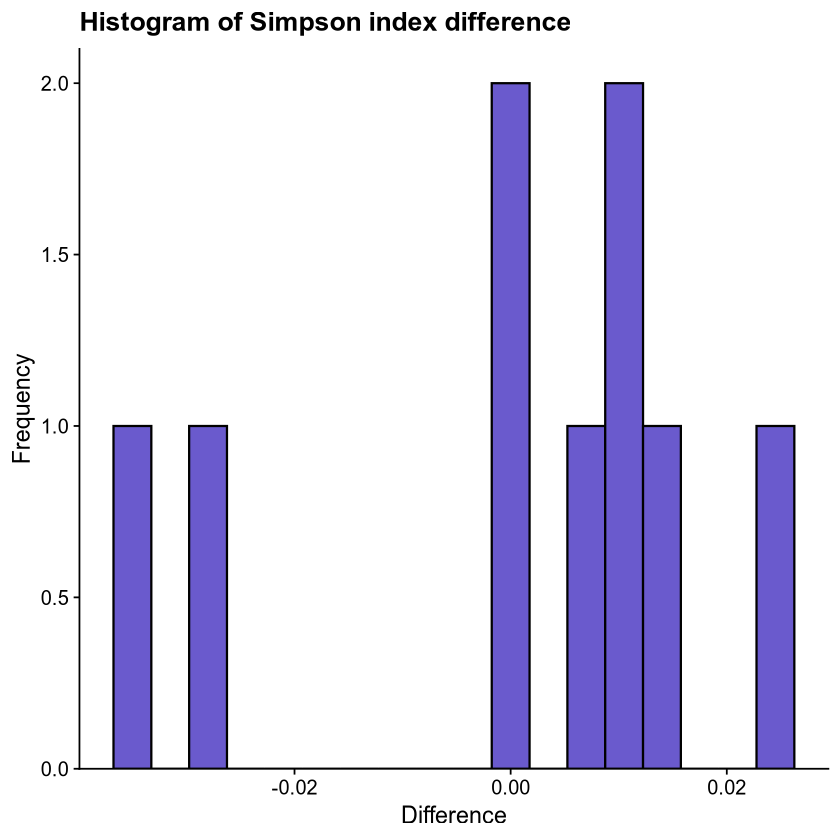

In [143]:
# Data distribution visualization
simpson_wide |> ggplot(aes(x = difference)) + 
  geom_histogram(binwidth = 0.0035, position = "identity", fill = "slateblue", col = "black") + 
  labs(
    title = "Histogram of Simpson index difference",
    x = "Difference",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open()

In [144]:
test_simpson <- t.test(Pair(Nulliparous, Primiparous) ~1, data = simpson_wide)
test_simpson


	Paired t-test

data:  Pair(Nulliparous, Primiparous)
t = -0.029123, df = 8, p-value = 0.9775
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -0.01466721  0.01430135
sample estimates:
mean difference 
  -0.0001829264 


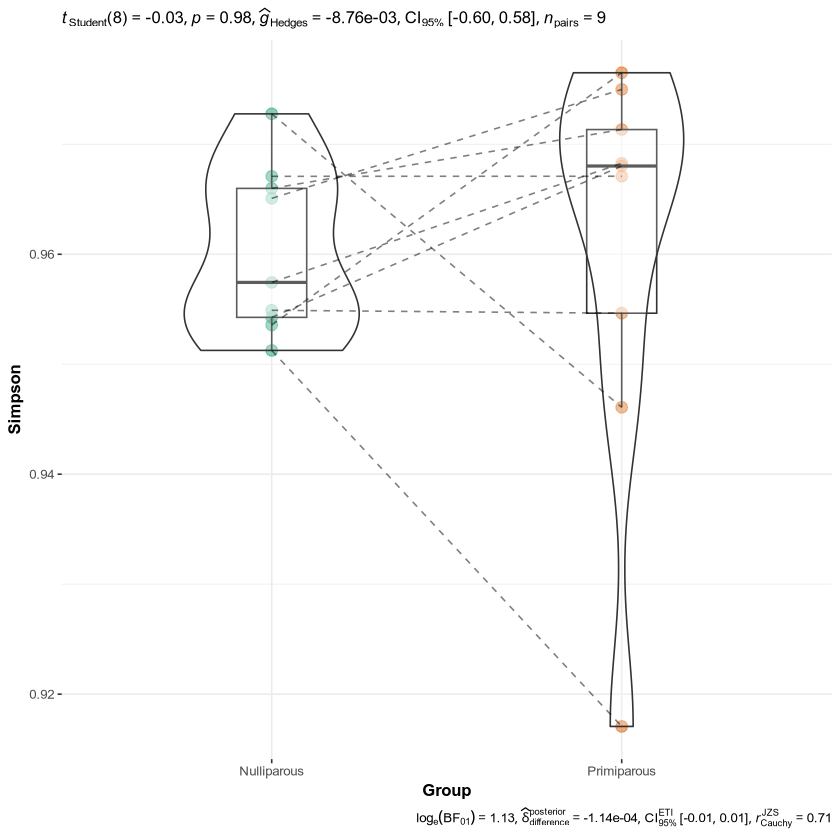

In [145]:
# view the data distribution
ggwithinstats( # paired samples
  data = df_simpson,
  x = Group,
  y = Simpson,
  #type = "nonparametric", # for wilcoxon
  centrality.plotting = FALSE # remove median
)

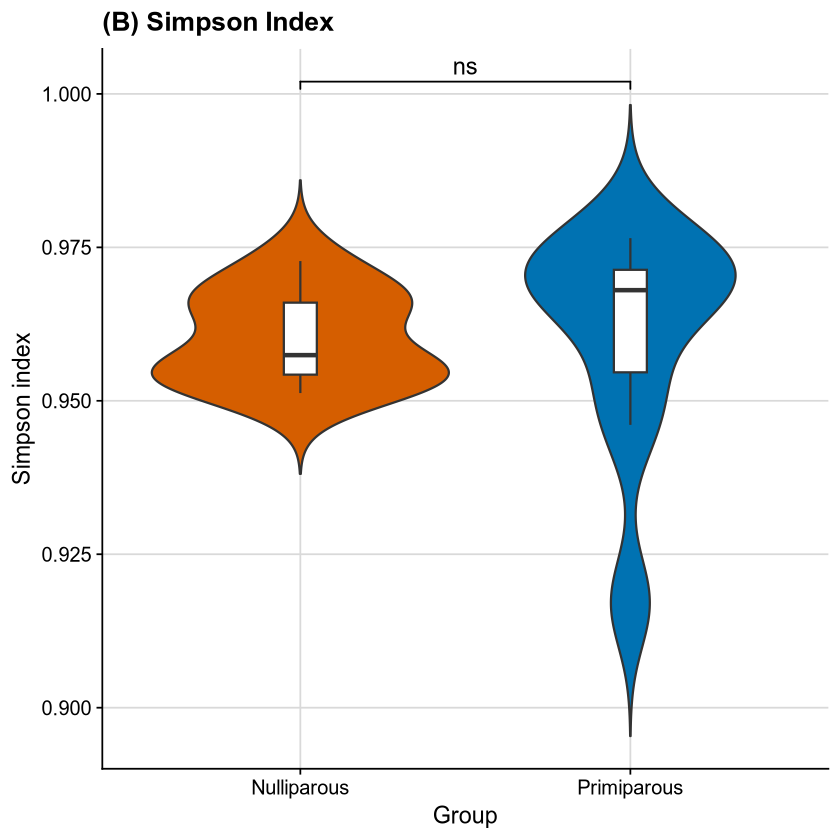

In [153]:
# Violin plots
plot_simpson <- df_simpson |> ggplot(aes(x = Group, y = Simpson, fill = Group)) +
  geom_violin(trim = FALSE) + 
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +
  scale_fill_manual(values = clr) +
  labs(
    x = "Group",
    y = "Simpson index",
    title = "(B) Simpson Index"
  ) +
  theme_half_open() +
  theme(legend.position = "none") +
  background_grid() +
  theme(legend.position = "none") +
geom_signif(
    annotations = "ns",                 
    y_position = 1.002,                 
    xmin = 1,
    xmax = 2,
    tip_length = 0.02,
    textsize = 5)

plot_simpson

# Combined plot~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

In [154]:
# remove legends so only one remains
plot_shannon_nl <- plot_shan +  guides(fill = "none", color = "none") 
plot_richness_nl <- plot_richness +  guides(fill = "none", color = "none") 

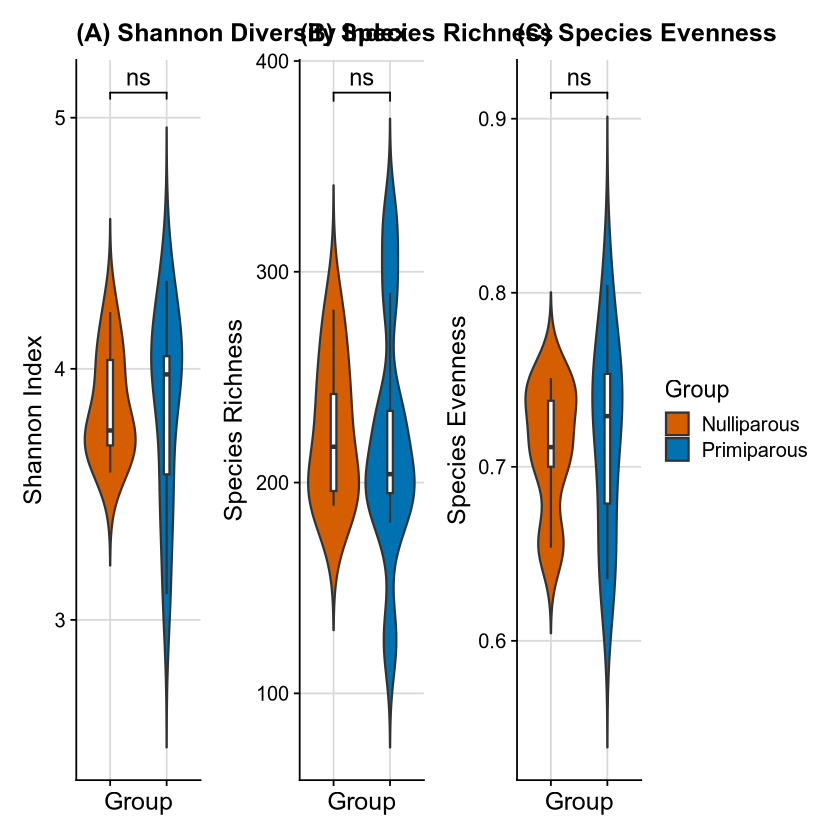

In [155]:
final_plot <-
  ( plot_shannon_nl | plot_richness_nl | plot_evenness) &
  theme_half_open() &
  background_grid() &
  theme(
    axis.text.x = element_blank(), # Remove Nulliparous etc
    plot.title = element_text(size = 15),
    axis.title = element_text(size = 15)
  )

final_plot

In [156]:
ggsave(file = paste0(Sys.Date(), "_saliva_alpha_tp1.pdf"), path ="/ceph/projects/010_SweMaMi/bm.nowak/plot_output/", 
       plot = final_plot, width = 14, height = 8)